# Exoplanet Candidate Classification with Leakage-Aware Evaluation

## Goal

This notebook builds a supervised machine learning model to classify Kepler Objects of Interest as either confirmed exoplanets or false positives.

The task is a binary classification problem:

- CONFIRMED: likely real exoplanet
- FALSE POSITIVE: signal is not a real exoplanet

## Main techniques

This notebook uses:

- binary classification
- leakage-aware feature selection
- group-aware splitting by host star ID
- model comparison
- logistic regression
- random forest
- extra trees
- histogram gradient boosting
- ROC-AUC and average precision
- threshold tuning
- confusion matrix analysis
- feature importance

In [ ]:
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
POSITIVE_LABEL = "CONFIRMED"
NEGATIVE_LABEL = "FALSE POSITIVE"

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
dataset_path = kagglehub.dataset_download("nasa/kepler-exoplanet-search-results")
dataset_path = Path(dataset_path)

print("Dataset downloaded to:", dataset_path)

csv_files = list(dataset_path.rglob("*.csv"))
csv_files

100%|██████████| 1.16M/1.16M [00:01<00:00, 1.03MB/s]

Extracting files...
Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\nasa\kepler-exoplanet-search-results\versions\2


[WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/nasa/kepler-exoplanet-search-results/versions/2/cumulative.csv')]

In [3]:
df = pd.read_csv(csv_files[0])

df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   str    
 3   kepler_name        2294 non-null   str    
 4   koi_disposition    9564 non-null   str    
 5   koi_pdisposition   9564 non-null   str    
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 non-null   

## Data loading 

The dataset loaded successfully with 9,564 rows and 50 columns.

Each row represents a Kepler Object of Interest with astronomical observation features, object identifiers, and disposition labels.

The original dataset includes both numerical measurements, such as orbital period, transit depth, planet radius, and stellar properties, as well as identifier and disposition-related columns.

In [5]:
df.columns = [col.strip().lower() for col in df.columns]

df.columns.tolist()[:30]

['rowid',
 'kepid',
 'kepoi_name',
 'kepler_name',
 'koi_disposition',
 'koi_pdisposition',
 'koi_score',
 'koi_fpflag_nt',
 'koi_fpflag_ss',
 'koi_fpflag_co',
 'koi_fpflag_ec',
 'koi_period',
 'koi_period_err1',
 'koi_period_err2',
 'koi_time0bk',
 'koi_time0bk_err1',
 'koi_time0bk_err2',
 'koi_impact',
 'koi_impact_err1',
 'koi_impact_err2',
 'koi_duration',
 'koi_duration_err1',
 'koi_duration_err2',
 'koi_depth',
 'koi_depth_err1',
 'koi_depth_err2',
 'koi_prad',
 'koi_prad_err1',
 'koi_prad_err2',
 'koi_teq']

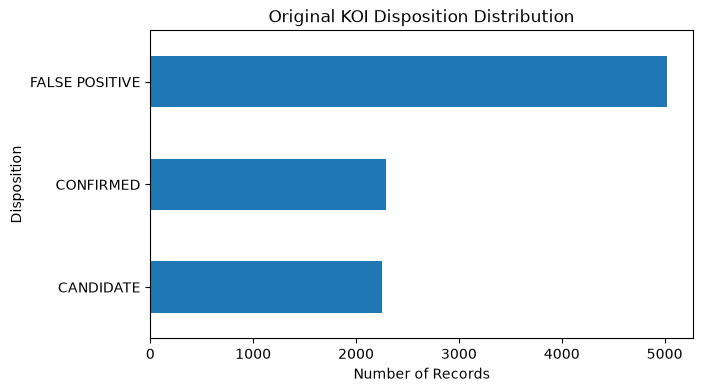

In [8]:
target_col = "koi_disposition"

plt.figure(figsize=(7, 4))
df[target_col].value_counts().sort_values().plot(kind="barh")
plt.title("Original KOI Disposition Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Disposition")
plt.show()

## Original target distribution

The original target column contains three disposition classes:

- FALSE POSITIVE: 5,023 records
- CONFIRMED: 2,293 records
- CANDIDATE: 2,248 records

Candidate rows were removed because they represent uncertain cases. This notebook focuses on a clearer binary classification task: confirmed exoplanets versus false positives.

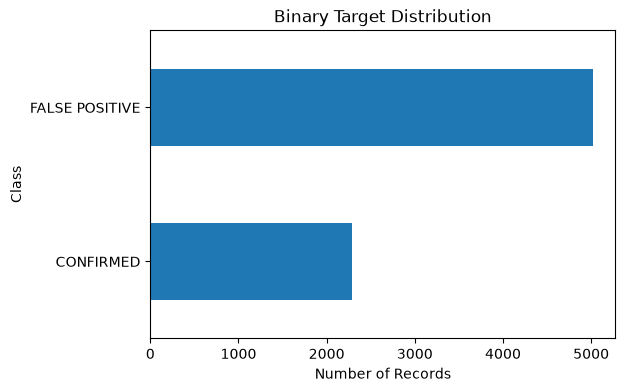

In [10]:
binary_df = df[df[target_col].isin([POSITIVE_LABEL, NEGATIVE_LABEL])].copy()

plt.figure(figsize=(6, 4))
binary_df[target_col].value_counts().sort_values().plot(kind="barh")
plt.title("Binary Target Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Class")
plt.show()

In [11]:
binary_df[target_col].value_counts()

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
Name: count, dtype: int64

In [12]:
df[target_col].value_counts(dropna=False)

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

In [14]:
binary_df = df[df[target_col].isin([POSITIVE_LABEL, NEGATIVE_LABEL])].copy()

binary_df[target_col].value_counts()

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
Name: count, dtype: int64

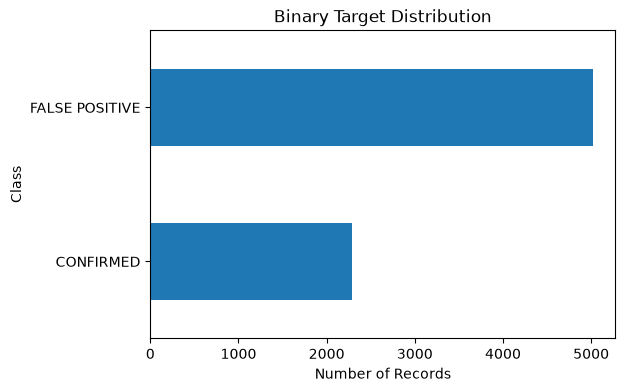

In [15]:
plt.figure(figsize=(6, 4))
binary_df[target_col].value_counts().sort_values().plot(kind="barh")
plt.title("Binary Target Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Class")
plt.show()

## Binary target

After removing CANDIDATE rows, the binary modelling dataset contained 7,316 rows.

The class distribution was:

- FALSE POSITIVE: 5,023 records
- CONFIRMED: 2,293 records

The dataset is moderately imbalanced, with false positives being the majority class. Because of this, F1-score, recall, precision, balanced accuracy, ROC-AUC, and average precision are more useful than accuracy alone.

In [17]:
possible_leakage_or_id_cols = [
    "koi_disposition",
    "koi_pdisposition",
    "koi_score",
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec",
    "kepid",
    "kepoi_name",
    "kepler_name",
    "koi_tce_delivname"
]

cols_to_drop = [col for col in possible_leakage_or_id_cols if col in binary_df.columns]

cols_to_drop

['koi_disposition',
 'koi_pdisposition',
 'koi_score',
 'koi_fpflag_nt',
 'koi_fpflag_ss',
 'koi_fpflag_co',
 'koi_fpflag_ec',
 'kepid',
 'kepoi_name',
 'kepler_name',
 'koi_tce_delivname']

In [18]:
feature_df = binary_df.drop(columns=cols_to_drop)

feature_df.head()

,rowid,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [19]:
y = binary_df[target_col].copy()

if "kepid" in binary_df.columns:
    groups = binary_df["kepid"].copy()
else:
    groups = pd.Series(np.arange(len(binary_df)), index=binary_df.index)

X = feature_df.copy()

print("Feature matrix:", X.shape)
print("Target:", y.shape)
print("Groups:", groups.shape)

Feature matrix: (7316, 39)
Target: (7316,)
Groups: (7316,)


## Leakage removal

Target-adjacent columns and major identifier columns were removed before modelling.

The removed columns included the target label, previous disposition, disposition score, false-positive flags, Kepler object names, host star ID, and TCE delivery name.

This is important because columns such as `koi_score`, `koi_pdisposition`, and false-positive flags can directly encode information about the final classification decision.

One issue remains: `rowid` was left in the feature matrix. It later appeared as the most important feature in permutation importance. Since `rowid` is an index-like identifier rather than a real astronomical measurement, it should not be interpreted scientifically. In a stricter rerun, `rowid` should also be removed.

In [20]:
missing_summary = X.isna().sum().sort_values(ascending=False)

missing_summary[missing_summary > 0].head(30)

koi_teq_err1         7316
koi_teq_err2         7316
koi_steff_err2        412
koi_srad_err1         397
koi_steff_err1        397
koi_slogg_err2        397
koi_slogg_err1        397
koi_srad_err2         397
koi_depth_err1        377
koi_impact_err1       377
koi_depth_err2        377
koi_period_err2       377
koi_time0bk_err1      377
koi_period_err1       377
koi_time0bk_err2      377
koi_duration_err2     377
koi_duration_err1     377
koi_impact_err2       377
koi_prad_err1         300
koi_srad              300
koi_slogg             300
koi_prad_err2         300
koi_depth             300
koi_prad              300
koi_impact            300
koi_model_snr         300
koi_teq               300
koi_steff             300
koi_tce_plnt_num      279
koi_insol_err2        259
dtype: int64

In [21]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical columns:")
print(categorical_features)

Numeric features: 39
Categorical features: 0

Categorical columns:
[]


In [22]:
X[numeric_features].describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
rowid,7316.0,4729.992482,2803.978558,1.000000e+00,2288.750000,4819.500000,7191.250000,9.564000e+03
koi_period,7316.0,58.816738,121.082398,2.418425e-01,2.237412,8.507657,36.184630,1.071233e+03
koi_period_err1,6939.0,0.002123,0.008496,1.100000e-08,0.000003,0.000022,0.000176,1.725000e-01
koi_period_err2,6939.0,-0.002123,0.008496,-1.725000e-01,-0.000176,-0.000022,-0.000003,-1.100000e-08
koi_time0bk,7316.0,164.877955,65.646366,1.205159e+02,132.588305,136.765693,170.882535,1.472522e+03
koi_time0bk_err1,6939.0,0.008911,0.021584,8.700000e-06,0.000865,0.003130,0.008835,5.690000e-01
koi_time0bk_err2,6939.0,-0.008911,0.021584,-5.690000e-01,-0.008835,-0.003130,-0.000865,-8.700000e-06
koi_impact,7016.0,0.796773,3.668625,0.000000e+00,0.224000,0.576000,0.916250,1.008060e+02
koi_impact_err1,6939.0,2.080036,9.651753,0.000000e+00,0.036000,0.182000,0.380500,8.554000e+01
koi_impact_err2,6939.0,-0.325324,1.220699,-3.753000e+01,-0.430900,-0.176000,-0.038000,0.000000e+00


## Feature inspection 

After leakage and identifier removal, the feature matrix contained 7,316 rows and 39 features.

All remaining model features were numerical.

Several columns had missing values, so median imputation was needed inside the preprocessing pipeline. Two columns, `koi_teq_err1` and `koi_teq_err2`, were fully missing in the binary dataset.

Most features are astronomical measurements related to orbital period, transit timing, transit depth, planet radius, equilibrium temperature, stellar properties, and sky position.

In [23]:
def plot_feature_by_class(data, feature, target):
    plot_data = data[[feature, target]].dropna()
    
    plt.figure(figsize=(7, 4))
    
    for label in [NEGATIVE_LABEL, POSITIVE_LABEL]:
        values = plot_data[plot_data[target] == label][feature]
        values = values.clip(
            lower=values.quantile(0.01),
            upper=values.quantile(0.99)
        )
        plt.hist(values, bins=40, alpha=0.6, label=label)
    
    plt.title(f"{feature} Distribution by Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [24]:
eda_df = binary_df.copy()

candidate_eda_features = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_steff",
    "koi_srad"
]

available_eda_features = [col for col in candidate_eda_features if col in eda_df.columns]

available_eda_features

['koi_period',
 'koi_duration',
 'koi_depth',
 'koi_prad',
 'koi_teq',
 'koi_insol',
 'koi_steff',
 'koi_srad']

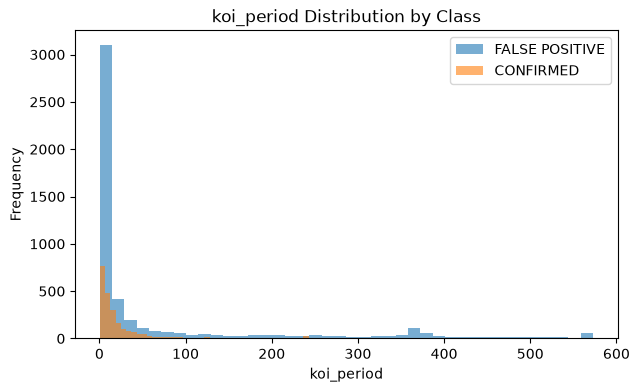

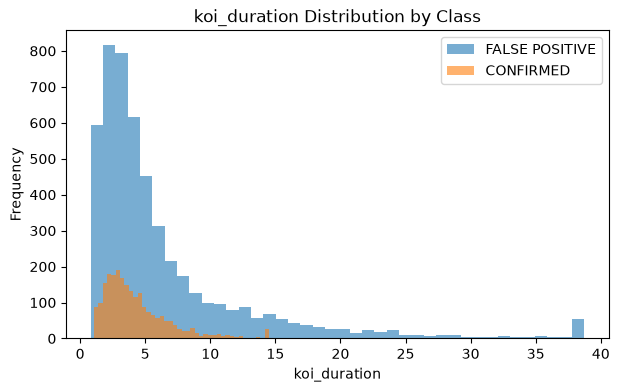

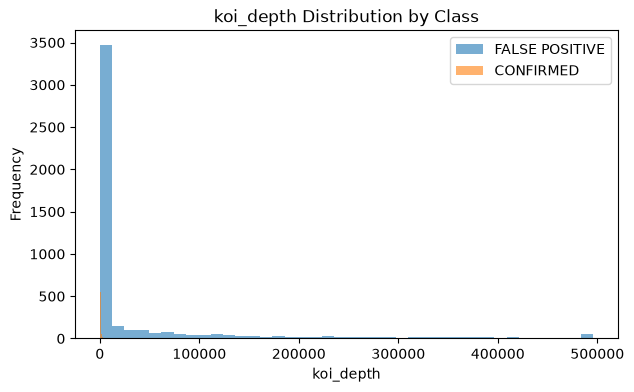

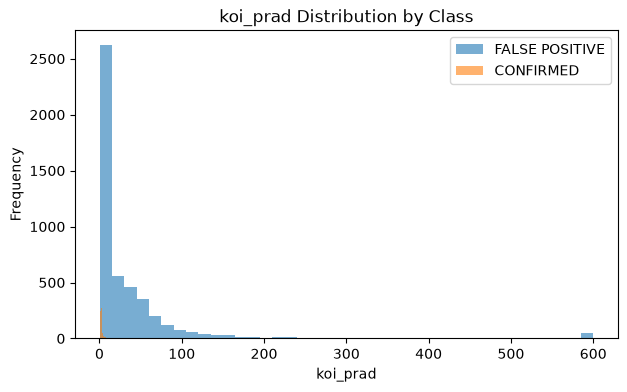

In [25]:
for feature in available_eda_features[:4]:
    plot_feature_by_class(eda_df, feature, target_col)

## EDA observations

The exploratory plots showed that confirmed exoplanets and false positives have different distributions for several transit and orbital features.

Features such as orbital period, transit duration, transit depth, and planet radius show class-level differences, but the distributions still overlap.

This means the problem is not perfectly separable using one simple threshold. A machine learning model is useful because it can combine multiple astronomical measurements at once.

In [26]:
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_val_idx, test_idx = next(gss_test.split(X, y, groups=groups))

X_train_val = X.iloc[train_val_idx].copy()
y_train_val = y.iloc[train_val_idx].copy()
groups_train_val = groups.iloc[train_val_idx].copy()

X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_test = groups.iloc[test_idx].copy()

In [27]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_idx_rel, val_idx_rel = next(
    gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
)

X_train = X_train_val.iloc[train_idx_rel].copy()
y_train = y_train_val.iloc[train_idx_rel].copy()
groups_train = groups_train_val.iloc[train_idx_rel].copy()

X_val = X_train_val.iloc[val_idx_rel].copy()
y_val = y_train_val.iloc[val_idx_rel].copy()
groups_val = groups_train_val.iloc[val_idx_rel].copy()

In [28]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTarget distribution:")
print("Train:")
print(y_train.value_counts(normalize=True))
print("\nValidation:")
print(y_val.value_counts(normalize=True))
print("\nTest:")
print(y_test.value_counts(normalize=True))

print("\nGroup overlap checks:")
print("Train ∩ Validation:", set(groups_train).intersection(set(groups_val)))
print("Train ∩ Test:", set(groups_train).intersection(set(groups_test)))
print("Validation ∩ Test:", set(groups_val).intersection(set(groups_test)))

Train: (4373, 39)
Validation: (1470, 39)
Test: (1473, 39)

Target distribution:
Train:
koi_disposition
FALSE POSITIVE    0.692888
CONFIRMED         0.307112
Name: proportion, dtype: float64

Validation:
koi_disposition
FALSE POSITIVE    0.679592
CONFIRMED         0.320408
Name: proportion, dtype: float64

Test:
koi_disposition
FALSE POSITIVE    0.674813
CONFIRMED         0.325187
Name: proportion, dtype: float64

Group overlap checks:
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [29]:
split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "groups": [
        groups_train.nunique(),
        groups_val.nunique(),
        groups_test.nunique()
    ],
    "confirmed_rate": [
        (y_train == POSITIVE_LABEL).mean(),
        (y_val == POSITIVE_LABEL).mean(),
        (y_test == POSITIVE_LABEL).mean()
    ]
})

split_summary

,split,rows,groups,confirmed_rate
0,Train,4373,3873,0.307112
1,Validation,1470,1291,0.320408
2,Test,1473,1291,0.325187


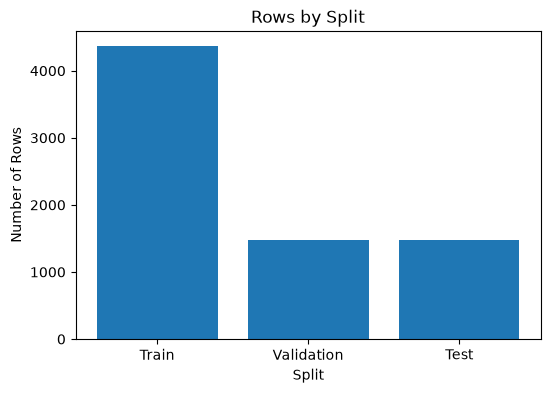

In [30]:
plt.figure(figsize=(6, 4))
plt.bar(split_summary["split"], split_summary["rows"])
plt.title("Rows by Split")
plt.xlabel("Split")
plt.ylabel("Number of Rows")
plt.show()

## Group-aware split

The dataset was split by host star ID so that objects from the same star system did not appear across training, validation, and test sets.

The final split was:

- Training set: 4,373 rows from 3,873 groups
- Validation set: 1,470 rows from 1,291 groups
- Test set: 1,473 rows from 1,291 groups

The confirmed exoplanet rate was similar across the splits:

- Train: 30.71%
- Validation: 32.04%
- Test: 32.52%

There was no group overlap between the train, validation, and test sets. This makes the evaluation more realistic than a random row split because the model must generalise to unseen star systems.

In [31]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [32]:
def positive_scores(model, X_data):
    classes = list(model.named_steps["model"].classes_)
    pos_index = classes.index(POSITIVE_LABEL)
    return model.predict_proba(X_data)[:, pos_index]

In [33]:
def evaluate_predictions(y_true, y_pred, y_score=None, model_name="Model"):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=POSITIVE_LABEL, zero_division=0)
    }
    
    if y_score is not None:
        y_binary = (y_true == POSITIVE_LABEL).astype(int)
        result["roc_auc"] = roc_auc_score(y_binary, y_score)
        result["average_precision"] = average_precision_score(y_binary, y_score)
    
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    
    for key, value in result.items():
        if key != "model":
            print(f"{key}: {value:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=[NEGATIVE_LABEL, POSITIVE_LABEL],
        zero_division=0
    ))
    
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[NEGATIVE_LABEL, POSITIVE_LABEL]
    )
    
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[NEGATIVE_LABEL, POSITIVE_LABEL]
    )
    
    display.plot()
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()
    
    return result

In [34]:
def plot_roc_curve_custom(y_true, y_score, model_name):
    y_binary = (y_true == POSITIVE_LABEL).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    auc = roc_auc_score(y_binary, y_score)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve: {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

In [36]:
def plot_precision_recall_curve_custom(y_true, y_score, model_name):
    y_binary = (y_true == POSITIVE_LABEL).astype(int)
    precision, recall, _ = precision_recall_curve(y_binary, y_score)
    ap = average_precision_score(y_binary, y_score)
    
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"Average Precision = {ap:.3f}")
    plt.title(f"Precision-Recall Curve: {model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

In [37]:
def find_best_f1_threshold(y_true, y_score):
    y_binary = (y_true == POSITIVE_LABEL).astype(int)
    
    precision, recall, thresholds = precision_recall_curve(y_binary, y_score)
    
    precision = precision[:-1]
    recall = recall[:-1]
    
    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    
    return {
        "threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx],
        "f1": f1_scores[best_idx]
    }

Dummy Baseline
accuracy: 0.6796
balanced_accuracy: 0.5000
precision: 0.0000
recall: 0.0000
f1: 0.0000

Classification Report:
                precision    recall  f1-score   support

FALSE POSITIVE       0.68      1.00      0.81       999
     CONFIRMED       0.00      0.00      0.00       471

      accuracy                           0.68      1470
     macro avg       0.34      0.50      0.40      1470
  weighted avg       0.46      0.68      0.55      1470



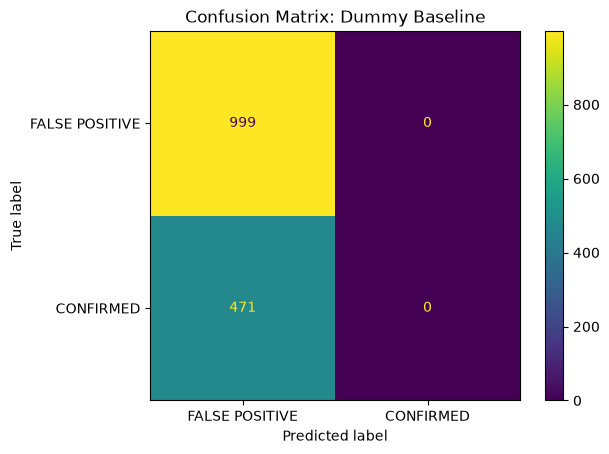

In [38]:
baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_val_preds = baseline_model.predict(X_val)

baseline_result = evaluate_predictions(
    y_true=y_val,
    y_pred=baseline_val_preds,
    model_name="Dummy Baseline"
)

## Baseline model

The dummy baseline achieved:

- Accuracy: 0.6796
- Balanced accuracy: 0.5000
- Precision: 0.0000
- Recall: 0.0000
- F1-score: 0.0000

The baseline predicted only the majority class, FALSE POSITIVE.

Although the accuracy looks moderate, the model completely failed to identify confirmed exoplanets. This shows why accuracy alone is misleading for this task.

Logistic Regression
accuracy: 0.9218
balanced_accuracy: 0.9301
precision: 0.8284
recall: 0.9533
f1: 0.8865
roc_auc: 0.9754
average_precision: 0.9478

Classification Report:
                precision    recall  f1-score   support

FALSE POSITIVE       0.98      0.91      0.94       999
     CONFIRMED       0.83      0.95      0.89       471

      accuracy                           0.92      1470
     macro avg       0.90      0.93      0.91      1470
  weighted avg       0.93      0.92      0.92      1470



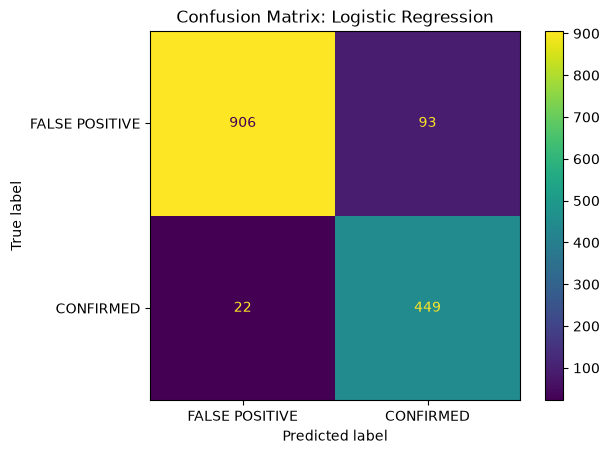

In [39]:
log_reg_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

log_reg_model.fit(X_train, y_train)

log_reg_val_scores = positive_scores(log_reg_model, X_val)
log_reg_val_preds = log_reg_model.predict(X_val)

log_reg_result = evaluate_predictions(
    y_true=y_val,
    y_pred=log_reg_val_preds,
    y_score=log_reg_val_scores,
    model_name="Logistic Regression"
)

## Logistic regression note

Logistic regression achieved strong validation performance:

- Accuracy: 0.9218
- Balanced accuracy: 0.9301
- Precision: 0.8284
- Recall: 0.9533
- F1-score: 0.8865
- ROC-AUC: 0.9754
- Average precision: 0.9478

The model had very high recall for confirmed exoplanets, meaning it successfully detected most confirmed cases. However, its precision was lower than the tree-based models, meaning it produced more false positive confirmed predictions.

This makes logistic regression a useful high-recall baseline.

Random Forest
accuracy: 0.9435
balanced_accuracy: 0.9355
precision: 0.9110
recall: 0.9130
f1: 0.9120
roc_auc: 0.9849
average_precision: 0.9647

Classification Report:
                precision    recall  f1-score   support

FALSE POSITIVE       0.96      0.96      0.96       999
     CONFIRMED       0.91      0.91      0.91       471

      accuracy                           0.94      1470
     macro avg       0.93      0.94      0.94      1470
  weighted avg       0.94      0.94      0.94      1470



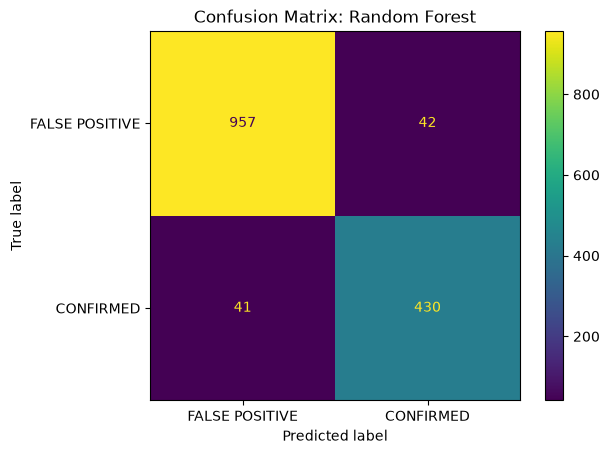

In [40]:
random_forest_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_val_scores = positive_scores(random_forest_model, X_val)
rf_val_preds = random_forest_model.predict(X_val)

rf_result = evaluate_predictions(
    y_true=y_val,
    y_pred=rf_val_preds,
    y_score=rf_val_scores,
    model_name="Random Forest"
)

## Random forest

The random forest model achieved:

- Accuracy: 0.9435
- Balanced accuracy: 0.9355
- Precision: 0.9110
- Recall: 0.9130
- F1-score: 0.9120
- ROC-AUC: 0.9849
- Average precision: 0.9647

Random forest improved precision compared with logistic regression while still keeping recall high.

This suggests that non-linear relationships between astronomical features are useful for separating confirmed exoplanets from false positives.

Extra Trees
accuracy: 0.9381
balanced_accuracy: 0.9371
precision: 0.8800
recall: 0.9342
f1: 0.9063
roc_auc: 0.9836
average_precision: 0.9628

Classification Report:
                precision    recall  f1-score   support

FALSE POSITIVE       0.97      0.94      0.95       999
     CONFIRMED       0.88      0.93      0.91       471

      accuracy                           0.94      1470
     macro avg       0.92      0.94      0.93      1470
  weighted avg       0.94      0.94      0.94      1470



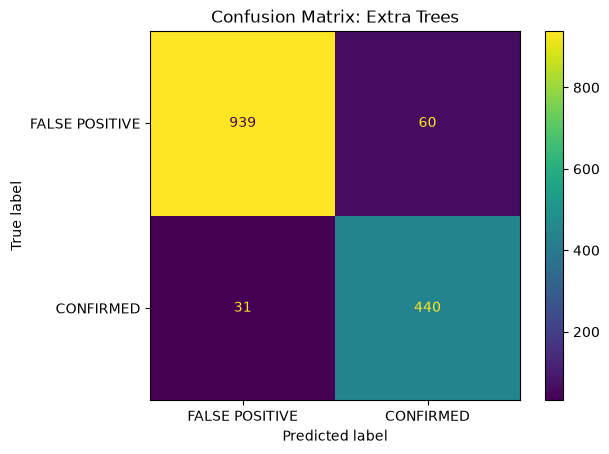

In [41]:
extra_trees_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", ExtraTreesClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

extra_trees_model.fit(X_train, y_train)

extra_val_scores = positive_scores(extra_trees_model, X_val)
extra_val_preds = extra_trees_model.predict(X_val)

extra_result = evaluate_predictions(
    y_true=y_val,
    y_pred=extra_val_preds,
    y_score=extra_val_scores,
    model_name="Extra Trees"
)

## Extra Trees 

The Extra Trees model achieved:

- Accuracy: 0.9381
- Balanced accuracy: 0.9371
- Precision: 0.8800
- Recall: 0.9342
- F1-score: 0.9063
- ROC-AUC: 0.9836
- Average precision: 0.9628

Extra Trees performed strongly and had higher recall than random forest, but lower precision.

Overall, it was competitive, but it did not outperform histogram gradient boosting on validation F1-score.

HistGradientBoosting
accuracy: 0.9537
balanced_accuracy: 0.9469
precision: 0.9278
recall: 0.9278
f1: 0.9278
roc_auc: 0.9890
average_precision: 0.9728

Classification Report:
                precision    recall  f1-score   support

FALSE POSITIVE       0.97      0.97      0.97       999
     CONFIRMED       0.93      0.93      0.93       471

      accuracy                           0.95      1470
     macro avg       0.95      0.95      0.95      1470
  weighted avg       0.95      0.95      0.95      1470



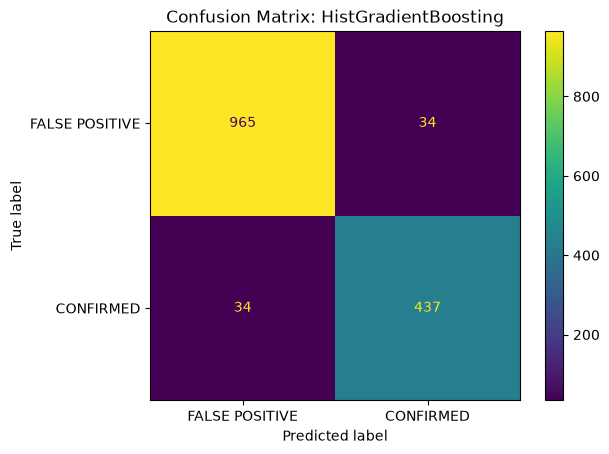

In [42]:
hist_gb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ))
])

hist_gb_model.fit(X_train, y_train)

hist_val_scores = positive_scores(hist_gb_model, X_val)
hist_val_preds = hist_gb_model.predict(X_val)

hist_result = evaluate_predictions(
    y_true=y_val,
    y_pred=hist_val_preds,
    y_score=hist_val_scores,
    model_name="HistGradientBoosting"
)

## Histogram gradient boosting 

Histogram gradient boosting achieved the best validation performance:

- Accuracy: 0.9537
- Balanced accuracy: 0.9469
- Precision: 0.9278
- Recall: 0.9278
- F1-score: 0.9278
- ROC-AUC: 0.9890
- Average precision: 0.9728

This model produced the best balance between precision and recall for confirmed exoplanets.

It also achieved the highest ROC-AUC and average precision, showing that its probability scores separated confirmed exoplanets from false positives very well.

In [43]:
results_df = pd.DataFrame([
    baseline_result,
    log_reg_result,
    rf_result,
    extra_result,
    hist_result
])

results_df.sort_values("f1", ascending=False)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
4,HistGradientBoosting,0.953741,0.946890,0.927813,0.927813,0.927813,0.988991,0.972790
2,Random Forest,0.943537,0.935455,0.911017,0.912951,0.911983,0.984881,0.964681
3,Extra Trees,0.938095,0.937061,0.880000,0.934183,0.906282,0.983604,0.962806
1,Logistic Regression,0.921769,0.930099,0.828413,0.953291,0.886476,0.975428,0.947773
0,Dummy Baseline,0.679592,0.500000,0.000000,0.000000,0.000000,NaN,NaN


<Figure size 1100x500 with 0 Axes>

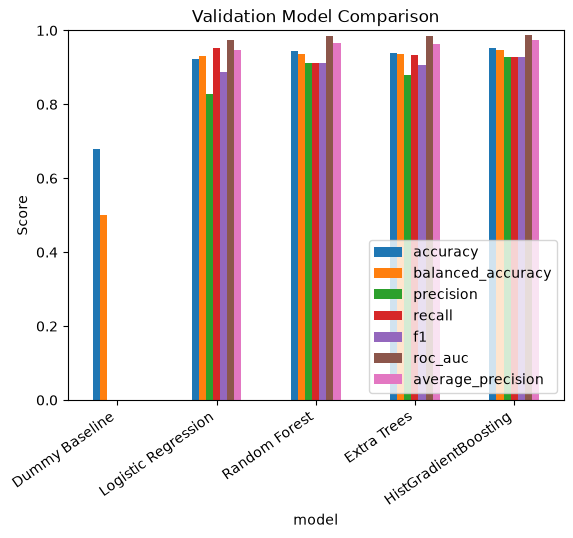

In [44]:
metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]

available_metrics = [metric for metric in metrics_to_plot if metric in results_df.columns]

plot_df = results_df.set_index("model")[available_metrics]

plt.figure(figsize=(11, 5))
plot_df.plot(kind="bar")
plt.title("Validation Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## Validation comparison

The best validation model was HistGradientBoosting.

Validation results:

| Model | Accuracy | Balanced accuracy | Precision | Recall | F1-score | ROC-AUC | Average precision |
|---|---:|---:|---:|---:|---:|---:|---:|
| HistGradientBoosting | 0.9537 | 0.9469 | 0.9278 | 0.9278 | 0.9278 | 0.9890 | 0.9728 |
| Random Forest | 0.9435 | 0.9355 | 0.9110 | 0.9130 | 0.9120 | 0.9849 | 0.9647 |
| Extra Trees | 0.9381 | 0.9371 | 0.8800 | 0.9342 | 0.9063 | 0.9836 | 0.9628 |
| Logistic Regression | 0.9218 | 0.9301 | 0.8284 | 0.9533 | 0.8865 | 0.9754 | 0.9478 |
| Dummy Baseline | 0.6796 | 0.5000 | 0.0000 | 0.0000 | 0.0000 | N/A | N/A |

Histogram gradient boosting was selected because it achieved the highest validation F1-score while also having the strongest ROC-AUC and average precision.

In [60]:
model_lookup = {
    "Dummy Baseline": baseline_model,
    "Logistic Regression": log_reg_model,
    "Random Forest": random_forest_model,
    "Extra Trees": extra_trees_model,
    "HistGradientBoosting": hist_gb_model
}

score_lookup = {
    "Logistic Regression": log_reg_val_scores,
    "Random Forest": rf_val_scores,
    "Extra Trees": extra_val_scores,
    "HistGradientBoosting": hist_val_scores
}

best_model_name = (
    results_df[results_df["model"] != "Dummy Baseline"]
    .sort_values("f1", ascending=False)
    .iloc[0]["model"]
)

best_model = model_lookup[best_model_name]
best_val_scores = score_lookup[best_model_name]

print("Best validation model:", best_model_name)

Best validation model: HistGradientBoosting


In [46]:
best_threshold_info = find_best_f1_threshold(
    y_true=y_val,
    y_score=best_val_scores
)

best_threshold_info

{'threshold': np.float64(0.4984802469747964),
 'precision': np.float64(0.9279661016949152),
 'recall': np.float64(0.9299363057324841),
 'f1': np.float64(0.9289501590168081)}

## Threshold tuning

The threshold was tuned on the validation set to maximise F1-score for confirmed exoplanets.

The best validation threshold was approximately 0.4985.

This is very close to the default threshold of 0.5, so threshold tuning did not meaningfully change the final classification behaviour.

The tuned validation threshold achieved:

- Precision: 0.9280
- Recall: 0.9299
- F1-score: 0.9290

In [47]:
test_scores = positive_scores(best_model, X_test)

test_preds_default = best_model.predict(X_test)
test_preds_tuned = np.where(
    test_scores >= best_threshold_info["threshold"],
    POSITIVE_LABEL,
    NEGATIVE_LABEL
)

HistGradientBoosting, Test Set, Default Threshold
accuracy: 0.9532
balanced_accuracy: 0.9447
precision: 0.9343
recall: 0.9207
f1: 0.9274
roc_auc: 0.9878
average_precision: 0.9789

Classification Report:
                precision    recall  f1-score   support

FALSE POSITIVE       0.96      0.97      0.97       994
     CONFIRMED       0.93      0.92      0.93       479

      accuracy                           0.95      1473
     macro avg       0.95      0.94      0.95      1473
  weighted avg       0.95      0.95      0.95      1473



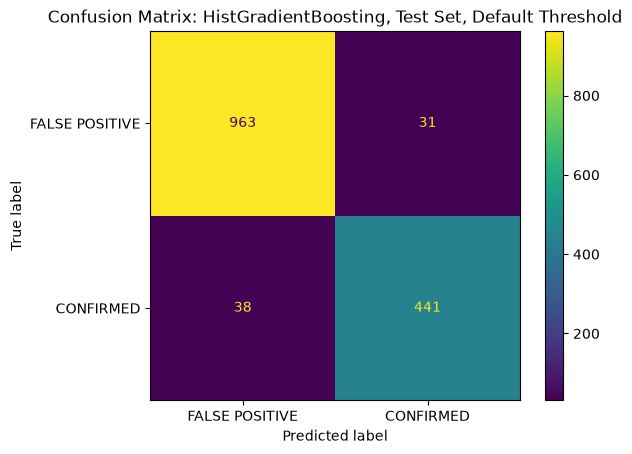

In [48]:
test_default_result = evaluate_predictions(
    y_true=y_test,
    y_pred=test_preds_default,
    y_score=test_scores,
    model_name=f"{best_model_name}, Test Set, Default Threshold"
)

HistGradientBoosting, Test Set, Tuned Threshold
accuracy: 0.9532
balanced_accuracy: 0.9447
precision: 0.9343
recall: 0.9207
f1: 0.9274
roc_auc: 0.9878
average_precision: 0.9789

Classification Report:
                precision    recall  f1-score   support

FALSE POSITIVE       0.96      0.97      0.97       994
     CONFIRMED       0.93      0.92      0.93       479

      accuracy                           0.95      1473
     macro avg       0.95      0.94      0.95      1473
  weighted avg       0.95      0.95      0.95      1473



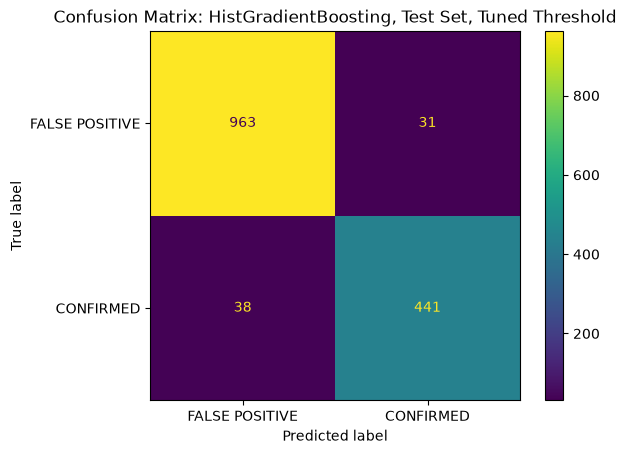

In [49]:
test_tuned_result = evaluate_predictions(
    y_true=y_test,
    y_pred=test_preds_tuned,
    y_score=test_scores,
    model_name=f"{best_model_name}, Test Set, Tuned Threshold"
)

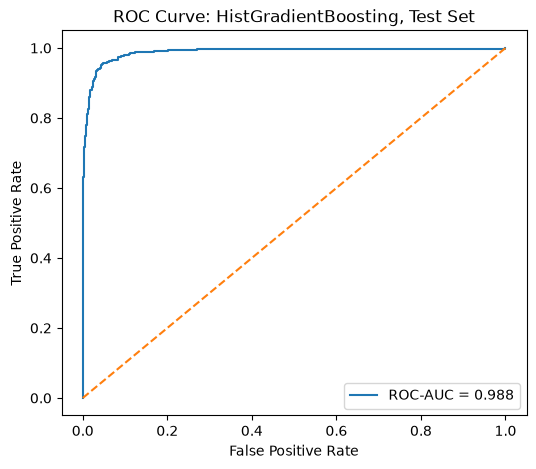

In [50]:
plot_roc_curve_custom(
    y_true=y_test,
    y_score=test_scores,
    model_name=f"{best_model_name}, Test Set"
)

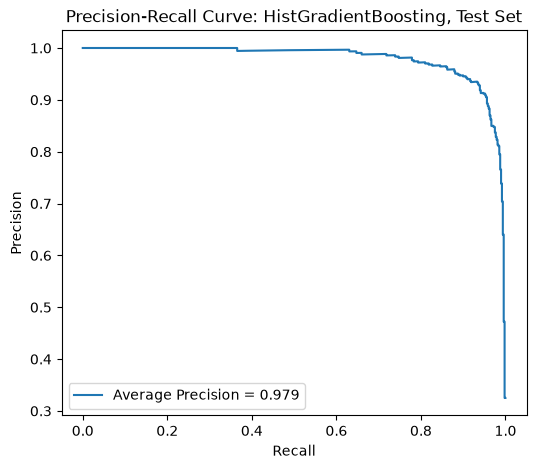

In [51]:
plot_precision_recall_curve_custom(
    y_true=y_test,
    y_score=test_scores,
    model_name=f"{best_model_name}, Test Set"
)

## Final test result

The selected model was HistGradientBoosting.

Using the tuned threshold, the test performance was:

- Accuracy: 0.9532
- Balanced accuracy: 0.9447
- Precision: 0.9343
- Recall: 0.9207
- F1-score: 0.9274
- ROC-AUC: 0.9878
- Average precision: 0.9789

The tuned threshold gave the same test result as the default threshold because the selected threshold was very close to 0.5.

The final model performed strongly on unseen host-star groups, with high precision and recall for confirmed exoplanets.

In [52]:
test_analysis = X_test.copy()
test_analysis["true_label"] = y_test.values
test_analysis["predicted_label"] = test_preds_tuned
test_analysis["confirmed_probability"] = test_scores
test_analysis["correct"] = test_analysis["true_label"] == test_analysis["predicted_label"]

test_analysis.head()

,rowid,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,...,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,true_label,predicted_label,confirmed_probability,correct
13,14,3.709214,0.000007,-0.000007,133.983180,0.001430,-0.001430,0.051,0.395,-0.051,...,1.022,0.143,-0.107,295.64871,48.495560,12.772,CONFIRMED,CONFIRMED,0.999946,True
18,19,9.273582,0.000010,-0.000010,173.258155,0.000877,-0.000877,0.387,0.004,-0.386,...,0.696,0.056,-0.068,288.13824,47.724449,15.302,CONFIRMED,CONFIRMED,0.999059,True
26,27,4.996780,0.000014,-0.000014,171.742080,0.002190,-0.002190,0.710,0.006,-0.533,...,0.847,0.161,-0.069,297.80826,47.946671,15.861,CONFIRMED,CONFIRMED,0.962371,True
38,39,2.701288,0.000006,-0.000006,170.695790,0.001640,-0.001640,1.016,3.967,-0.059,...,0.910,0.228,-0.105,297.92365,48.777321,15.540,FALSE POSITIVE,FALSE POSITIVE,0.004172,True
40,41,19.651210,0.000006,-0.000006,179.401981,0.000249,-0.000249,0.723,0.010,-0.020,...,1.063,0.336,-0.144,291.09390,48.933842,15.536,FALSE POSITIVE,FALSE POSITIVE,0.292475,True


In [53]:
error_cases = test_analysis[test_analysis["correct"] == False].copy()

print("Number of errors:", len(error_cases))
print("Error rate:", len(error_cases) / len(test_analysis))

Number of errors: 69
Error rate: 0.04684317718940937


In [54]:
error_cases[["true_label", "predicted_label", "confirmed_probability"]].head(20)

,true_label,predicted_label,confirmed_probability
170,CONFIRMED,FALSE POSITIVE,0.283897
313,CONFIRMED,FALSE POSITIVE,0.002042
371,FALSE POSITIVE,CONFIRMED,0.954023
501,FALSE POSITIVE,CONFIRMED,0.667128
567,FALSE POSITIVE,CONFIRMED,0.833164
674,CONFIRMED,FALSE POSITIVE,0.426785
834,FALSE POSITIVE,CONFIRMED,0.786789
948,CONFIRMED,FALSE POSITIVE,0.018726
973,FALSE POSITIVE,CONFIRMED,0.991218
1095,CONFIRMED,FALSE POSITIVE,0.369404


In [55]:
high_confidence_errors = error_cases.copy()

high_confidence_errors["confidence"] = np.where(
    high_confidence_errors["predicted_label"] == POSITIVE_LABEL,
    high_confidence_errors["confirmed_probability"],
    1 - high_confidence_errors["confirmed_probability"]
)

high_confidence_errors = high_confidence_errors.sort_values(
    "confidence",
    ascending=False
)

high_confidence_errors[
    ["true_label", "predicted_label", "confirmed_probability", "confidence"]
].head(15)

,true_label,predicted_label,confirmed_probability,confidence
8821,CONFIRMED,FALSE POSITIVE,0.000003,0.999997
5349,CONFIRMED,FALSE POSITIVE,0.000093,0.999907
3430,FALSE POSITIVE,CONFIRMED,0.999263,0.999263
3589,CONFIRMED,FALSE POSITIVE,0.000745,0.999255
313,CONFIRMED,FALSE POSITIVE,0.002042,0.997958
4645,CONFIRMED,FALSE POSITIVE,0.003955,0.996045
1609,FALSE POSITIVE,CONFIRMED,0.993289,0.993289
2154,FALSE POSITIVE,CONFIRMED,0.992531,0.992531
1733,CONFIRMED,FALSE POSITIVE,0.007728,0.992272
973,FALSE POSITIVE,CONFIRMED,0.991218,0.991218


## Error analysis

The final tuned model made 69 errors on the test set, giving an error rate of about 4.68%.

Some errors were high-confidence mistakes. These are especially important because they show cases where the model was strongly confident but wrong.

Examples included confirmed exoplanets predicted as false positives with very low confirmed probabilities, and false positives predicted as confirmed with very high confirmed probabilities.

This suggests that some objects have feature patterns that closely resemble the opposite class, or that important information may be missing from the tabular features.

In [ ]:
f1_scorer = make_scorer(
    f1_score,
    pos_label=POSITIVE_LABEL,
    zero_division=0
)

perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring=f1_scorer,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_result.importances_mean,
    "std": perm_result.importances_std
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance,std
0,rowid,0.064734,0.009261
16,koi_prad,0.047563,0.006476
7,koi_impact,0.036755,0.009285
1,koi_period,0.025046,0.003163
11,koi_duration_err1,0.017667,0.004754
28,koi_steff_err1,0.014988,0.005138
9,koi_impact_err2,0.014652,0.005070
2,koi_period_err1,0.011742,0.002804
25,koi_model_snr,0.011112,0.003766
10,koi_duration,0.010327,0.002835


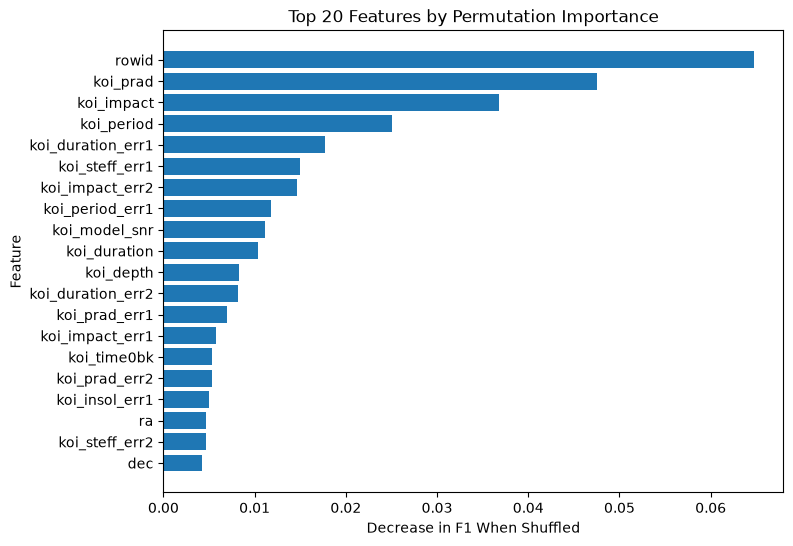

In [59]:
top_importance = importance_df.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"][::-1], top_importance["importance"][::-1])
plt.title("Top 20 Features by Permutation Importance")
plt.xlabel("Decrease in F1 When Shuffled")
plt.ylabel("Feature")
plt.show()

## Feature importance

Permutation importance showed that the most influential columns included:

- rowid
- koi_prad
- koi_impact
- koi_period
- koi_duration_err1
- koi_steff_err1
- koi_impact_err2
- koi_period_err1
- koi_model_snr
- koi_duration
- koi_depth

The appearance of `rowid` as the most important feature is a warning sign. Since `rowid` is an index-like identifier, it should not be interpreted as an astronomical feature. A stricter version of the notebook should remove `rowid` and rerun the model.

Ignoring `rowid`, the important features suggest that the model relied heavily on planet radius, transit impact, orbital period, transit duration, signal-to-noise ratio, and transit depth to separate confirmed exoplanets from false positives.